In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import equinox as eqx
from flowjax.flows import coupling_flow
from flowjax.distributions import Normal
from flowjax.bijections import Affine

from types import SimpleNamespace

import corner
import matplotlib.pyplot as plt
import numpy as np

from lisa_sbi_tutorial.model import load_model
from lisa_sbi_tutorial.noise import NoiseDataset
from lisa_sbi_tutorial.priors import PriorModel
from lisa_sbi_tutorial.signal import get_taylor_signal, lisa_asd
from lisa_sbi_tutorial.utils import Config


In [2]:
DEFAULT_CONFIG = Config()

In [3]:
# load model parameters
model = load_model("../models/trained_model")

In [4]:
def whiten_signal(freqs, signal):

    asd = lisa_asd(freqs)

    return signal / asd

def get_true_signal(freqs, theta):

    log10_distance, log10_mass = theta
    
    signal = get_taylor_signal(freqs, log10_distance_mpc=log10_distance, log10_mass=log10_mass)
    return signal

def get_whitened_signal(freqs, theta):

    log10_distance, log10_mass = theta
    
    signal = get_true_signal(freqs, theta)
    return whiten_signal(freqs, signal)

def get_random_draw_with_true_signal(experiment, key=None):

    if key is None:
        key = jax.random.key(123123132)

    batch_shape = (1,)
    theta = experiment.prior_model.sample(key, batch_shape=batch_shape, return_array=True)[0]
    signal = get_whitened_signal(experiment.noise_model.frequencies, theta)

    noise = experiment.noise_model.sample(jax.random.key(1), batch_shape=batch_shape)
    data = signal.real + noise[0]

    return theta, signal, data

In [5]:
priors_dict = {
    "log10_distance_mpc": {"type": "uniform", "min": 4.0, "max": 6.0},
    "log10_mass": {"type": "uniform", "min": 1.0, "max": 3.0}
}

freqs = DEFAULT_CONFIG.freqs
noise_model = NoiseDataset(freqs)
prior_model = PriorModel(priors_dict)

experiment = SimpleNamespace(
    noise_model=noise_model,
    prior_model=prior_model,
    simulator=get_whitened_signal,
)

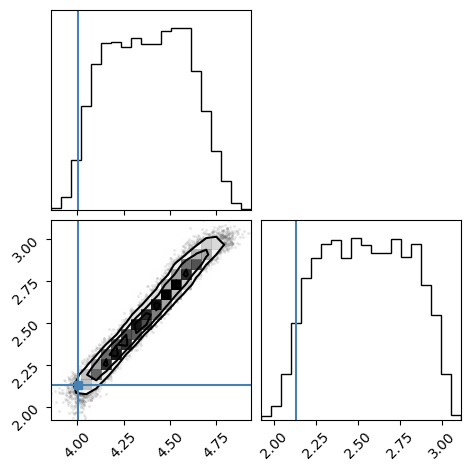

In [6]:
params, true_signal, data = get_random_draw_with_true_signal(experiment, key=jax.random.key(123450))
samples = model.sample(jax.random.key(1), condition=data, n_samples=10_000,)

corner.corner(
    np.array(samples),
    truths=np.array(params),
);

# Statistical coverage test

In [7]:
def get_percentile_of_truth(samples, truth):

    return jnp.sum(samples < truth, axis=0) / samples.shape[0]

In [ ]:
@eqx.filter_jit
def get_percentiles_from_random_observation(key):

    key_prior, key = jax.random.split(key)
    params, _, data = get_random_draw_with_true_signal(experiment, key=key)

    key1, key2 = jax.random.split(key)
    samples = model.sample(key2, n_samples=1_000, condition=data)

    return get_percentile_of_truth(samples, params)

get_percentiles_from_random_observation(jax.random.key(187912))

Array([0.018, 0.04 ], dtype=float64)

In [9]:
percentiles = jnp.array([get_percentiles_from_random_observation(jax.random.key(i)) for i in range(1000)])

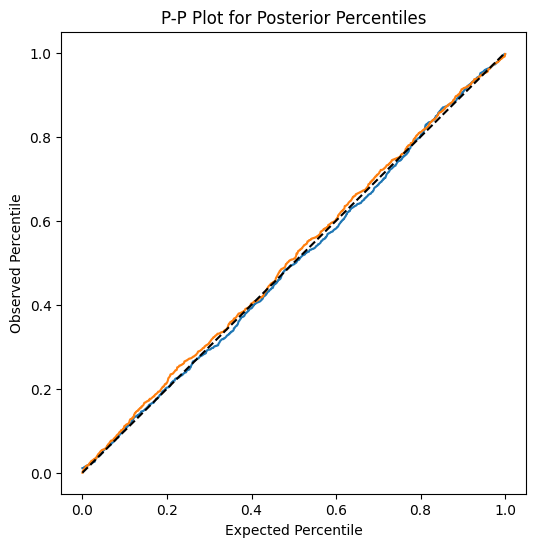

In [10]:
plt.figure(figsize=(6, 6))

for i in range(percentiles.shape[1]):
    sorted_percentiles = jnp.sort(percentiles[:, i])
    plt.plot(jnp.linspace(0, 1, len(sorted_percentiles)), sorted_percentiles)

plt.plot([0, 1], [0, 1], color='k', linestyle='--')
plt.xlabel('Expected Percentile')
plt.ylabel('Observed Percentile')
plt.title('P-P Plot for Posterior Percentiles')
plt.show()